In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display plots in notebook
%matplotlib inline

In [5]:
# Load dataset
df = pd.read_csv('train.csv')

# View first rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# Shape of dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (1460, 81)


In [ ]:
# Column names
print(df.columns)

# Dataset information
df.info()

Dataset Shape: (1460, 81)
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
      

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
# Our target is: SalePrice -- That’s what we want to predict.

In [ ]:
#Visualize House Prices
plt.figure(figsize=(10,6))

sns.histplot(df['SalePrice'], kde=True)

plt.title('Distribution of Sale Prices')

plt.xlabel('Sale Price')

plt.ylabel('Frequency')

plt.show()

In [ ]:
#Check Missing Values
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


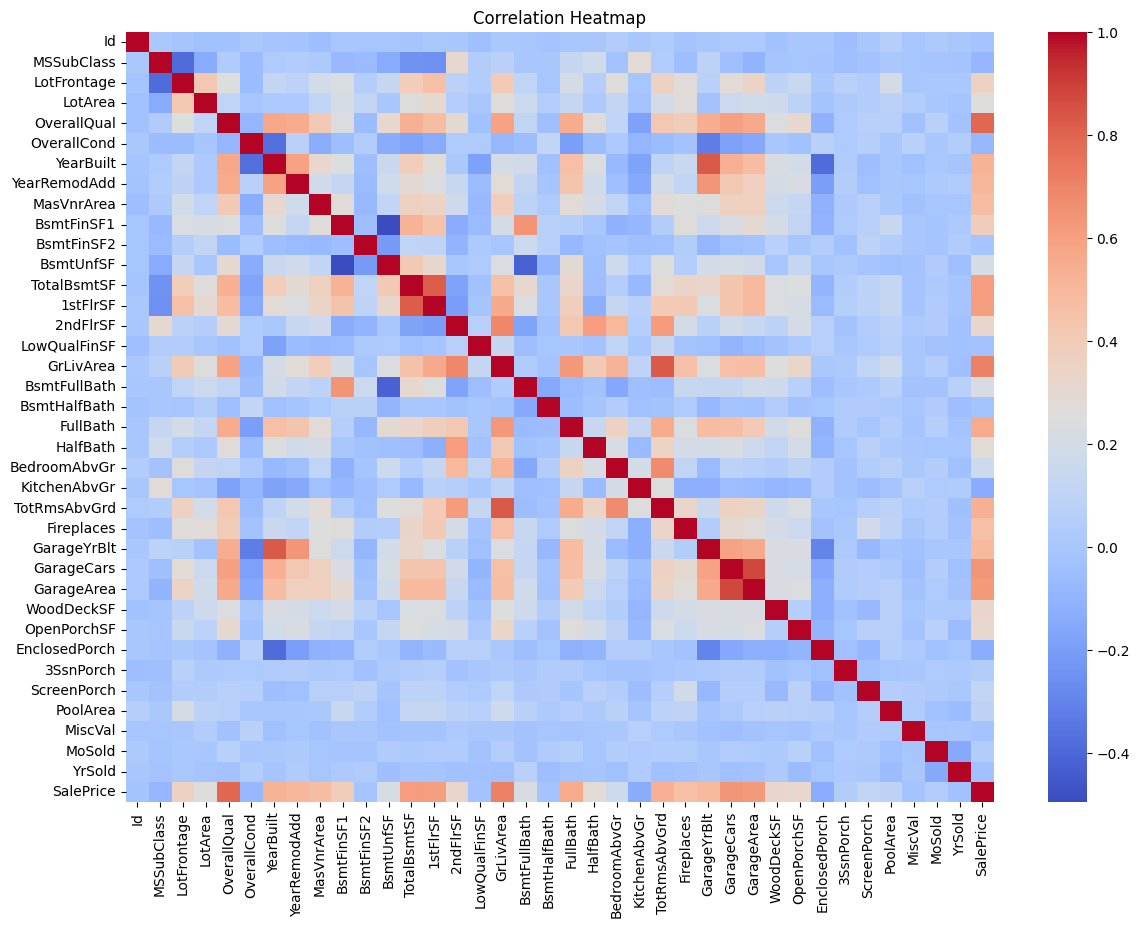

In [ ]:
#Correlation Heatmap
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(correlation, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
saleprice_corr = correlation['SalePrice'].sort_values(ascending=False)

print(saleprice_corr.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


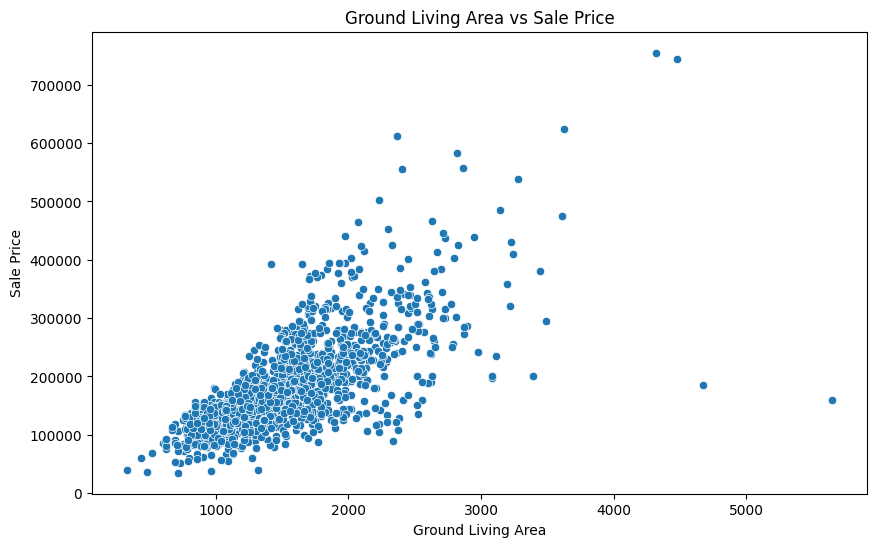

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])

plt.title('Ground Living Area vs Sale Price')

plt.xlabel('Ground Living Area')

plt.ylabel('Sale Price')

plt.show()

In [ ]:
#Data Cleaning
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

#missing PoolQC usually means: the house has no pool

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [ ]:
#Calculate Percentage Missing
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(ascending=False)

#This helps decide:

# -which columns to drop
# -which to fill

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


In [ ]:
#Drop Columns With Too Many Missing Values
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

df.drop(columns=columns_to_drop, inplace=True)

print("Updated Shape:", df.shape)

Updated Shape: (1460, 77)


In [ ]:
categorical_fill_none = [
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2'
]

for col in categorical_fill_none:
    df[col] = df[col].fillna('None')

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())


#Why median?

#Housing prices and sizes are often skewed.
#Median handles outliers better than mean.

In [ ]:
df.isnull().sum().sum()

np.int64(873)

In [ ]:
remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

remaining_missing.sort_values(ascending=False)

,0
MasVnrType,872
Electrical,1


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna('None')

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# Fill Numerical Missing Values
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

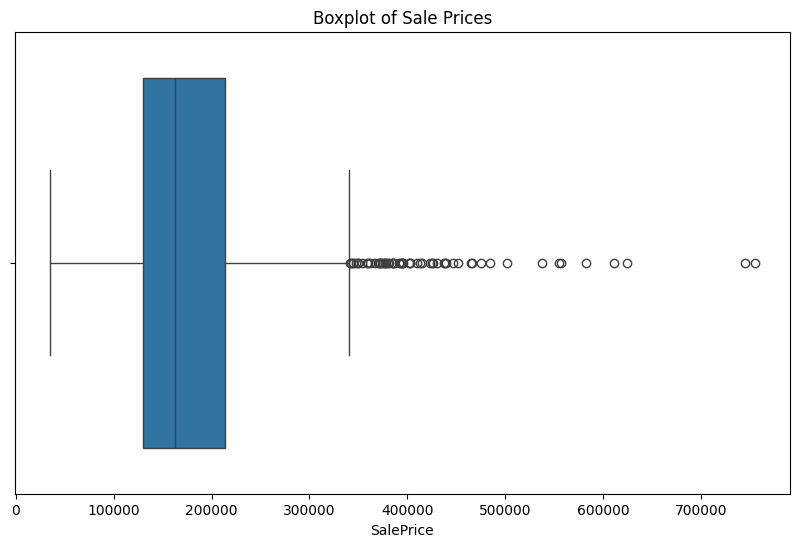

In [7]:
# Detect Outliers
plt.figure(figsize=(10,6))

sns.boxplot(x=df['SalePrice'])

plt.title('Boxplot of Sale Prices')

plt.show()

In [ ]:
# Remove Extreme Outliers
df = df.drop(df[(df['GrLivArea'] > 4000) &
                (df['SalePrice'] < 300000)].index)

print(df.shape)

(1458, 77)


In [ ]:
# Machine learning performs better with more normal distributions.
# apply logarithmic transformation
df['SalePrice'] = np.log1p(df['SalePrice'])

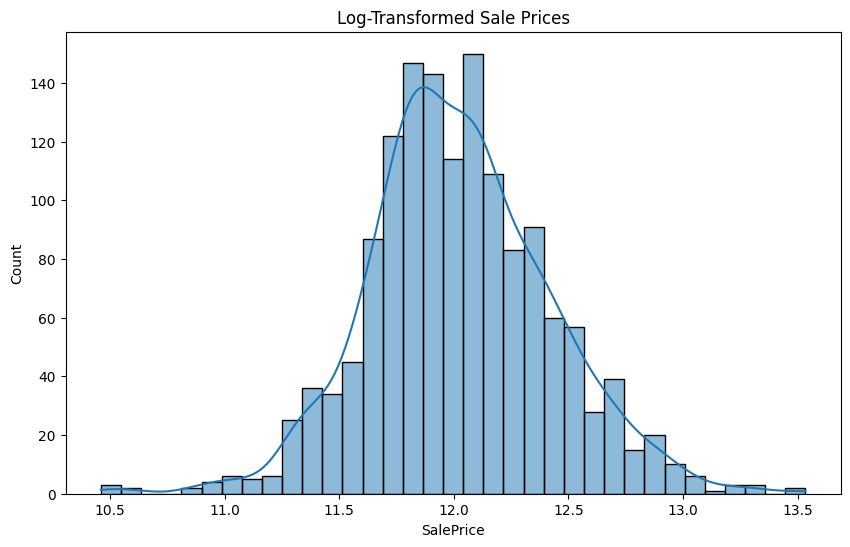

In [ ]:
# New transformed Distribution
plt.figure(figsize=(10,6))

sns.histplot(df['SalePrice'], kde=True)

plt.title('Log-Transformed Sale Prices')

plt.show()

In [10]:
# Features
X = df.drop('SalePrice', axis=1)

# Target
y = df['SalePrice']

In [18]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)



,0
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageYrBlt,81
GarageFinish,81
GarageType,81
GarageQual,81
GarageCond,81
BsmtExposure,38
BsmtFinType2,38


In [21]:
# Fill all categorical missing values with 'None'
categorical_cols = df.select_dtypes(include=['object']).columns

df[categorical_cols] = df[categorical_cols].fillna('None')

In [22]:
# Fill all numerical missing values with the median
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [24]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(1460, 245)


In [28]:
# Check which columns still have missing values
missing_cols = X.columns[X.isnull().any()]

print(missing_cols)
print(X[missing_cols].isnull().sum())

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='object')
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64


In [29]:
# Fill remaining missing numerical values

X['LotFrontage'] = X['LotFrontage'].fillna(X['LotFrontage'].median())

X['MasVnrArea'] = X['MasVnrArea'].fillna(X['MasVnrArea'].median())

X['GarageYrBlt'] = X['GarageYrBlt'].fillna(X['GarageYrBlt'].median())

In [30]:
print("Remaining Missing Values:", X.isnull().sum().sum())

Remaining Missing Values: 0


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [34]:
# Make Predictions

predictions = model.predict(X_test)

predictions[:10]

#output: these are log-transformed sale prices

array([159859.60675125, 348018.36498687,  83487.74607698, 175104.91846634,
       326629.29928128,  68399.06269555, 233151.48141241, 147031.02552995,
        63846.85472529, 151457.63439568])

In [35]:
# Evaluate the Model

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("Linear Regression Results")
print("-" * 30)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results
------------------------------
MAE: 20498.50715690966
MSE: 2429423922.5297537
RMSE: 49289.186669387775
R² Score: 0.6832698040595231


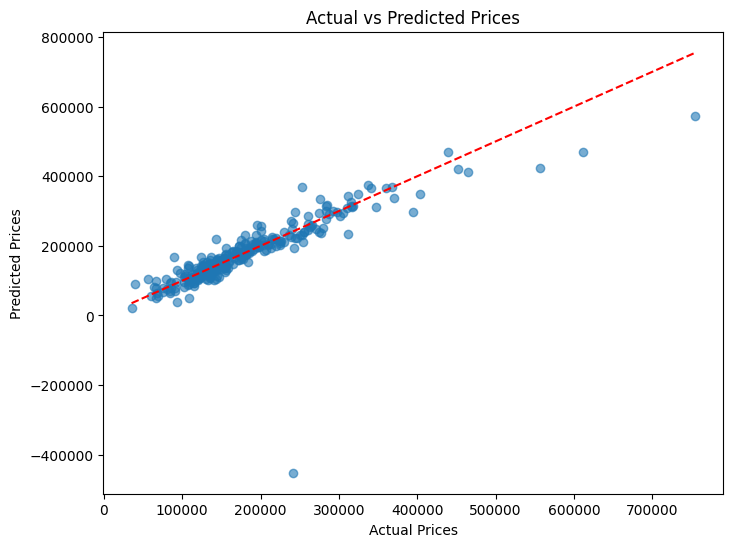

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

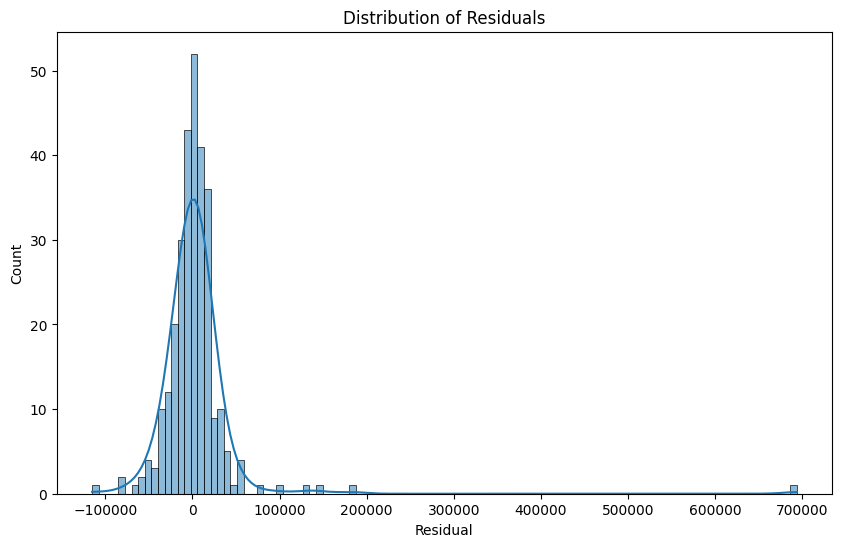

In [37]:
# Check Residual Errors

residuals = y_test - predictions

plt.figure(figsize=(10,6))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.show()

In [38]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute",
    ascending=False
)

coefficients.head(20)

,Feature,Coefficient,Absolute
113,RoofMatl_Metal,658820.608606,658820.608606
117,RoofMatl_WdShngl,624444.671903,624444.671903
115,RoofMatl_Tar&Grv,617544.825101,617544.825101
114,RoofMatl_Roll,616281.926404,616281.926404
111,RoofMatl_CompShg,614721.600066,614721.600066
116,RoofMatl_WdShake,611622.416022,611622.416022
91,Condition2_PosN,-233052.694195,233052.694195
216,GarageQual_Po,-178385.734870,178385.734870
214,GarageQual_Fa,-164369.125775,164369.125775
215,GarageQual_Gd,-160276.098482,160276.098482


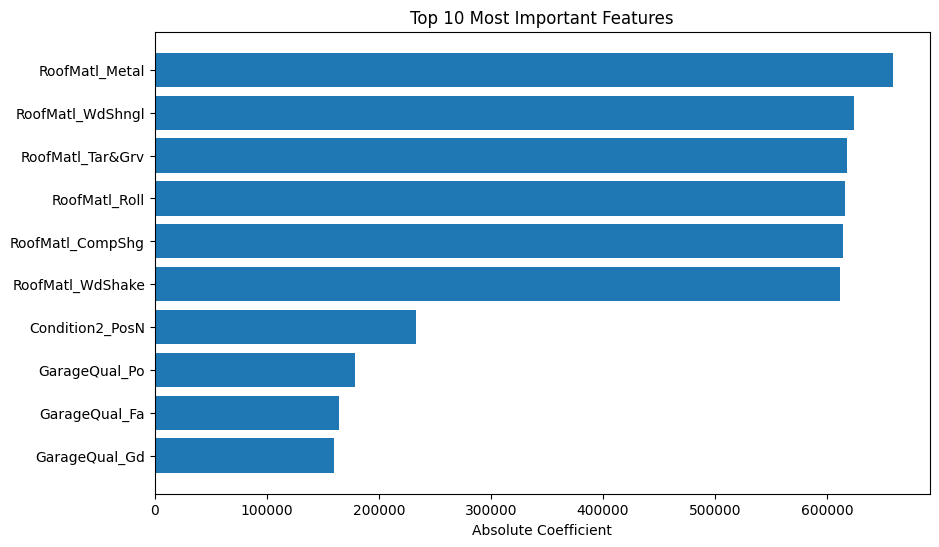

In [39]:
top_features = coefficients.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Absolute"])

plt.title("Top 10 Most Important Features")

plt.xlabel("Absolute Coefficient")

plt.gca().invert_yaxis()

plt.show()

In [40]:
#Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

In [41]:
# Create Decision Tree model

dt_model = DecisionTreeRegressor(random_state=42)

# Train model

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [42]:
# Make Predictions

dt_predictions = dt_model.predict(X_test)

In [43]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_mse = mean_squared_error(y_test, dt_predictions)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Results")
print("-"*30)
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Results
------------------------------
MAE: 26986.465753424658
MSE: 1723824122.6164384
RMSE: 41518.96100116715
R² Score: 0.7752606504530135


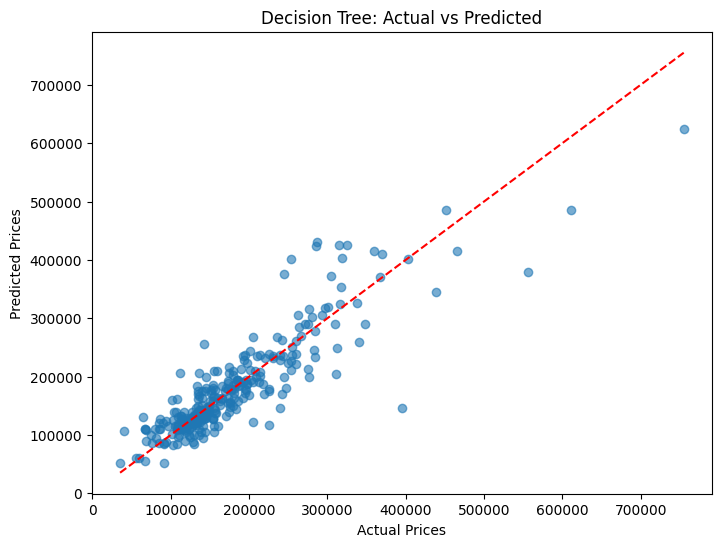

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, dt_predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Decision Tree: Actual vs Predicted")

plt.show()

In [45]:
#Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

In [46]:
# Create Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [47]:
rf_predictions = rf_model.predict(X_test)

In [48]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("-"*30)
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
------------------------------
MAE: 17672.178133561643
MSE: 832223736.3749158
RMSE: 28848.288274608527
R² Score: 0.891500867903751


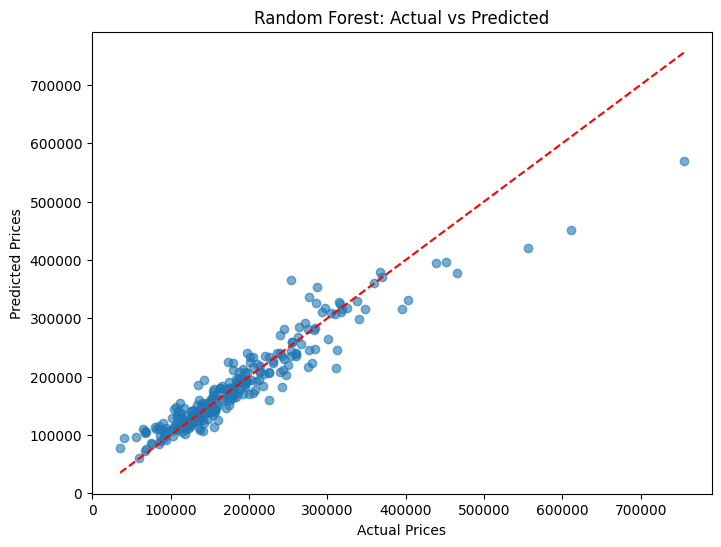

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,20498.507157,49289.186669,0.683270
1,Decision Tree,26986.465753,41518.961001,0.775261
2,Random Forest,17672.178134,28848.288275,0.891501


In [53]:
comparison.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
2,Random Forest,17672.178134,28848.288275,0.891501
1,Decision Tree,26986.465753,41518.961001,0.775261
0,Linear Regression,20498.507157,49289.186669,0.683270


In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
4,OverallQual,0.558716
16,GrLivArea,0.122976
12,TotalBsmtSF,0.034194
14,2ndFlrSF,0.031208
13,1stFlrSF,0.028499
9,BsmtFinSF1,0.028055
3,LotArea,0.018038
27,GarageArea,0.015275
26,GarageCars,0.014997
6,YearBuilt,0.013491


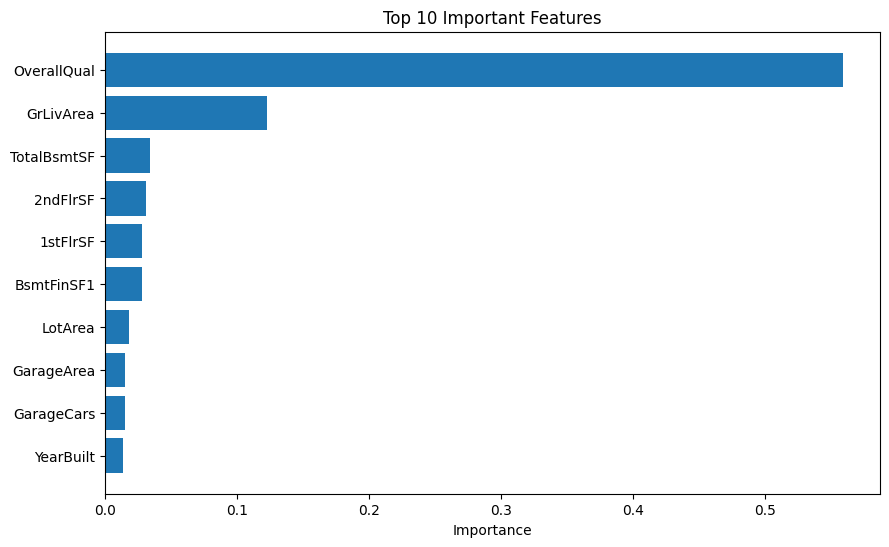

In [55]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [56]:
sample_house = X.iloc[[0]]

predicted_price = rf_model.predict(sample_house)

print("Predicted Log Sale Price:", predicted_price[0])

print("Predicted Sale Price:", np.expm1(predicted_price[0]))

Predicted Log Sale Price: 207517.64
Predicted Sale Price: inf
